In [ ]:
%pip install pandas matplotlib trino

## Connection to Database

In [2]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from trino.dbapi import connect
from trino.auth import BasicAuthentication, OAuth2Authentication

TRINO_HOST = "turing-embedded-data-science-fte-mode.trino.galaxy.starburst.io"
TRINO_CATALOG = "trainline_data"


private_path = Path("private.json")

if private_path.exists():
    creds = json.loads(private_path.read_text())
    db_user = creds["email"]
    db_password = creds["password"]
    auth = BasicAuthentication(db_user, db_password)
else:
    db_user = os.getenv("db_user") or os.getenv("TRINO_USER")
    db_password = os.getenv("db_password") or os.getenv("TRINO_PASSWORD")

    if db_user and db_password:
        auth = BasicAuthentication(db_user, db_password)
    else:
        # Fall back to OAuth if no private.json / password creds are available
        db_user = db_user or os.getenv("EMAIL") or os.getenv("USER")
        auth = OAuth2Authentication()

conn = locals().get(
    "conn",
    connect(
        auth=auth,
        http_scheme="https",
        host=TRINO_HOST,
        port=443,
        user=db_user,
        catalog=TRINO_CATALOG,
    ),
)

## Getting Meta Spend Trend

### This is everyone - even people who didnt accept cookies

In [18]:
daily_meta_spend = """
SELECT
    DATE(activity_date) as activity_date,
    channel_0,
    channel_1,
    channel_2,
    region,
    SUM(marketing_spend_gbp) AS spend_gbp,
    SUM(new_customer_count) AS new_customer_count,
    SUM(platform_conversions_nc) AS Meta_NC

FROM bi_dwh.marketing_yield
WHERE original_attribution = FALSE
    AND DATE(activity_date) >= DATE '2025-11-05'
    AND region = 'United Kingdom'
    AND channel_0 = 'Web - Paid Social'
    AND channel_2 = 'Facebook'
GROUP BY 1,2,3,4,5
ORDER BY 1
"""

meta_spend_df = pd.read_sql(daily_meta_spend, conn)

/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_37070/2785538361.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  meta_spend_df = pd.read_sql(daily_meta_spend, conn)


In [19]:
meta_spend_df


,activity_date,channel_0,channel_1,channel_2,region,spend_gbp,new_customer_count,Meta_NC
0,2025-11-05,Web - Paid Social,Paid Social,Facebook,United Kingdom,2882.219999,158.0,548.0
1,2025-11-06,Web - Paid Social,Paid Social,Facebook,United Kingdom,2856.000000,143.0,486.0
2,2025-11-07,Web - Paid Social,Paid Social,Facebook,United Kingdom,2331.380000,167.0,519.0
3,2025-11-08,Web - Paid Social,Paid Social,Facebook,United Kingdom,2534.609999,166.0,456.0
4,2025-11-09,Web - Paid Social,Paid Social,Facebook,United Kingdom,2565.880000,108.0,347.0
...,...,...,...,...,...,...,...,...
220,2026-06-13,Web - Paid Social,Paid Social,Facebook,United Kingdom,0.000000,240.0,20.0
221,2026-06-14,Web - Paid Social,Paid Social,Facebook,United Kingdom,0.000000,186.0,9.0
222,2026-06-15,Web - Paid Social,Paid Social,Facebook,United Kingdom,0.000000,191.0,1.0
223,2026-06-16,Web - Paid Social,Paid Social,Facebook,United Kingdom,NaN,228.0,NaN


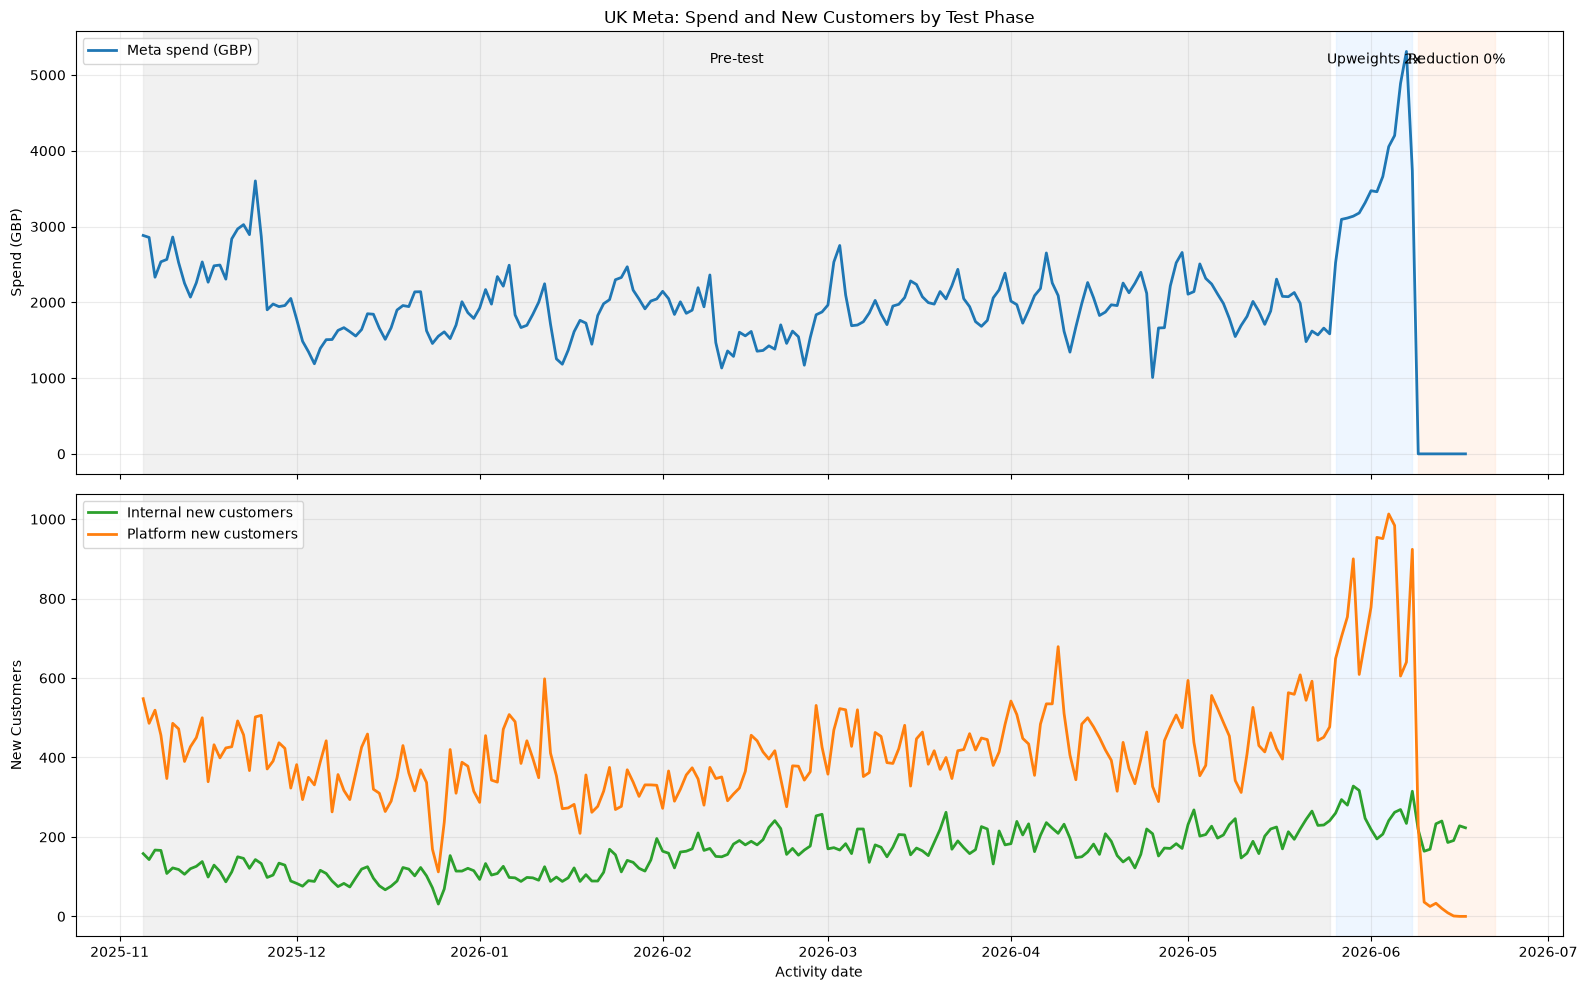

,phase,days,total_spend_gbp,internal_new_customers,platform_new_customers,internal_cpa_gbp,platform_cpa_gbp
0,Pre-test,202,395037.399985,31335.0,81080.0,12.606906,4.872193
1,Upweights 2x,14,51142.079997,3668.0,11159.0,13.942770,4.583034
2,Reduction 0%,9,0.000000,1852.0,346.0,0.000000,0.000000


In [21]:
# Phase definitions per Johnson (26 May upweight, 9 June downweight to 0%, 23 June restore)
PRE_TEST_START = pd.to_datetime('2025-11-05')
PRE_TEST_END = pd.to_datetime('2026-05-25')
UPWEIGHT_START = pd.to_datetime('2026-05-26')
UPWEIGHT_END = pd.to_datetime('2026-06-08')
REDUCTION_START = pd.to_datetime('2026-06-09')
REDUCTION_END = pd.to_datetime('2026-06-22')

plot_df = meta_spend_df.copy()
plot_df['activity_date'] = pd.to_datetime(plot_df['activity_date'])
plot_df = plot_df.sort_values('activity_date')

# Coerce to numeric and protect against nulls from source data
for col in ['spend_gbp', 'new_customer_count', 'Meta_NC']:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce').fillna(0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Top panel: spend
ax1.plot(plot_df['activity_date'], plot_df['spend_gbp'], color='tab:blue', linewidth=2, label='Meta spend (GBP)')
ax1.set_ylabel('Spend (GBP)')
ax1.set_title('UK Meta: Spend and New Customers by Test Phase')
ax1.grid(alpha=0.25)

# Bottom panel: internal vs platform new customers
ax2.plot(plot_df['activity_date'], plot_df['new_customer_count'], color='tab:green', linewidth=2, label='Internal new customers')
ax2.plot(plot_df['activity_date'], plot_df['Meta_NC'], color='tab:orange', linewidth=2, label='Platform new customers')
ax2.set_ylabel('New Customers')
ax2.set_xlabel('Activity date')
ax2.grid(alpha=0.25)

# Shade phases on both panels
phase_windows = [
    ('Pre-test', PRE_TEST_START, PRE_TEST_END, '#d9d9d9'),
    ('Upweights 2x', UPWEIGHT_START, UPWEIGHT_END, '#cfe8ff'),
    ('Reduction 0%', REDUCTION_START, REDUCTION_END, '#ffe0cc'),
]

for ax in (ax1, ax2):
    for phase_name, start_dt, end_dt, color in phase_windows:
        ax.axvspan(start_dt, end_dt, color=color, alpha=0.35)

# Put phase labels on top panel
y_top = ax1.get_ylim()[1]
for phase_name, start_dt, end_dt, _ in phase_windows:
    mid = start_dt + (end_dt - start_dt) / 2
    ax1.text(mid, y_top * 0.95, phase_name, ha='center', va='top', fontsize=10)

ax1.legend(loc='upper left')
ax2.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Optional quick KPI by phase
phase_summary = {
    'Pre-test': plot_df[(plot_df['activity_date'] >= PRE_TEST_START) & (plot_df['activity_date'] <= PRE_TEST_END)],
    'Upweights 2x': plot_df[(plot_df['activity_date'] >= UPWEIGHT_START) & (plot_df['activity_date'] <= UPWEIGHT_END)],
    'Reduction 0%': plot_df[(plot_df['activity_date'] >= REDUCTION_START) & (plot_df['activity_date'] <= REDUCTION_END)],
}

summary_rows = []
for phase, d in phase_summary.items():
    summary_rows.append({
        'phase': phase,
        'days': int(d['activity_date'].nunique()),
        'total_spend_gbp': float(d['spend_gbp'].sum()),
        'internal_new_customers': float(d['new_customer_count'].sum()),
        'platform_new_customers': float(d['Meta_NC'].sum()),
        'internal_cpa_gbp': float(d['spend_gbp'].sum() / d['new_customer_count'].sum()) if d['new_customer_count'].sum() > 0 else np.nan,
        'platform_cpa_gbp': float(d['spend_gbp'].sum() / d['Meta_NC'].sum()) if d['Meta_NC'].sum() > 0 else np.nan,
    })

pd.DataFrame(summary_rows)

## NTS Analysis: Platform vs Internal (Company-Attributed)

This section compares platform-reported transaction value (what Meta claims) vs internal attributed Net Sales (actual orders linked to Meta spend).

In [36]:
# NTS SQL Queries — adapted from Tom's Italy/Google approach for UK/Meta

# 1. Platform NTS: what Meta claims they drove (total_gross_sales_gbp from marketing_yield)
internal_platform_nts = """
SELECT
    DATE(activity_date) AS activity_date,
    channel_0,
    channel_1,
    channel_2,
    SUM(total_gross_sales_gbp) AS internal_nts,
    SUM(platform_conversions_trx_value_gbp) AS platform_nts
FROM bi_dwh.marketing_yield
WHERE original_attribution = FALSE
  AND region = 'United Kingdom'
  AND DATE(activity_date) >= DATE '2025-11-05'
  AND channel_0 = 'Web - Paid Social'
  AND channel_2 = 'Facebook'
GROUP BY 1,2,3,4
ORDER BY 1,2
"""


# 2. Total NTS 
total_nts = """
SELECT
    DATE(order_confirmed_date) AS activity_date,
    SUM(m_net_sales_amount_gbp) AS nts_gbp
FROM bi_dwh.fm_products fp
WHERE DATE(order_created_date) >= DATE('2025-11-05')
    -- standard fm_products filters
    AND record_type = 'SALES'
    AND order_id is not null
    AND order_confirmed_date is not null
    AND order_managed_group_id in ('20', '42')
    AND order_type_name not in ('change of journey', 'change over')
    -- business accounts
    AND LOWER(order_customer_id) NOT LIKE '%25kv%'
    AND order_region_name = 'United Kingdom'
GROUP BY 1
ORDER BY 1 """


In [37]:
# Execute all three queries
internal_platform_nts_df = pd.read_sql(internal_platform_nts, conn)
total_nts_df = pd.read_sql(total_nts, conn)
spend_daily_for_nts = meta_spend_df[['activity_date', 'spend_gbp']].copy()

# Aggregate platform/internal NTS to daily totals (across channels)
platform_daily = internal_platform_nts_df.groupby('activity_date').agg({
    'platform_nts': 'sum',
    'internal_nts': 'sum'
}).reset_index()
platform_daily['activity_date'] = pd.to_datetime(platform_daily['activity_date'])

# Aggregate baseline NTS to daily totals
baseline_daily = total_nts_df.groupby('activity_date').agg({
    'nts_gbp': 'sum'
}).reset_index()
baseline_daily['activity_date'] = pd.to_datetime(baseline_daily['activity_date'])
baseline_daily.rename(columns={'nts_gbp': 'baseline_nts_gbp'}, inplace=True)

# Convert spend dates and prepare for merge
spend_daily_for_nts['activity_date'] = pd.to_datetime(spend_daily_for_nts['activity_date'])

# Merge all data
nts_plot_df = platform_daily.merge(baseline_daily, on='activity_date', how='outer')
nts_plot_df = nts_plot_df.merge(spend_daily_for_nts, on='activity_date', how='outer')
nts_plot_df = nts_plot_df.sort_values('activity_date').fillna(0)


/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_37070/3071359227.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  internal_platform_nts_df = pd.read_sql(internal_platform_nts, conn)
/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_37070/3071359227.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  total_nts_df = pd.read_sql(total_nts, conn)


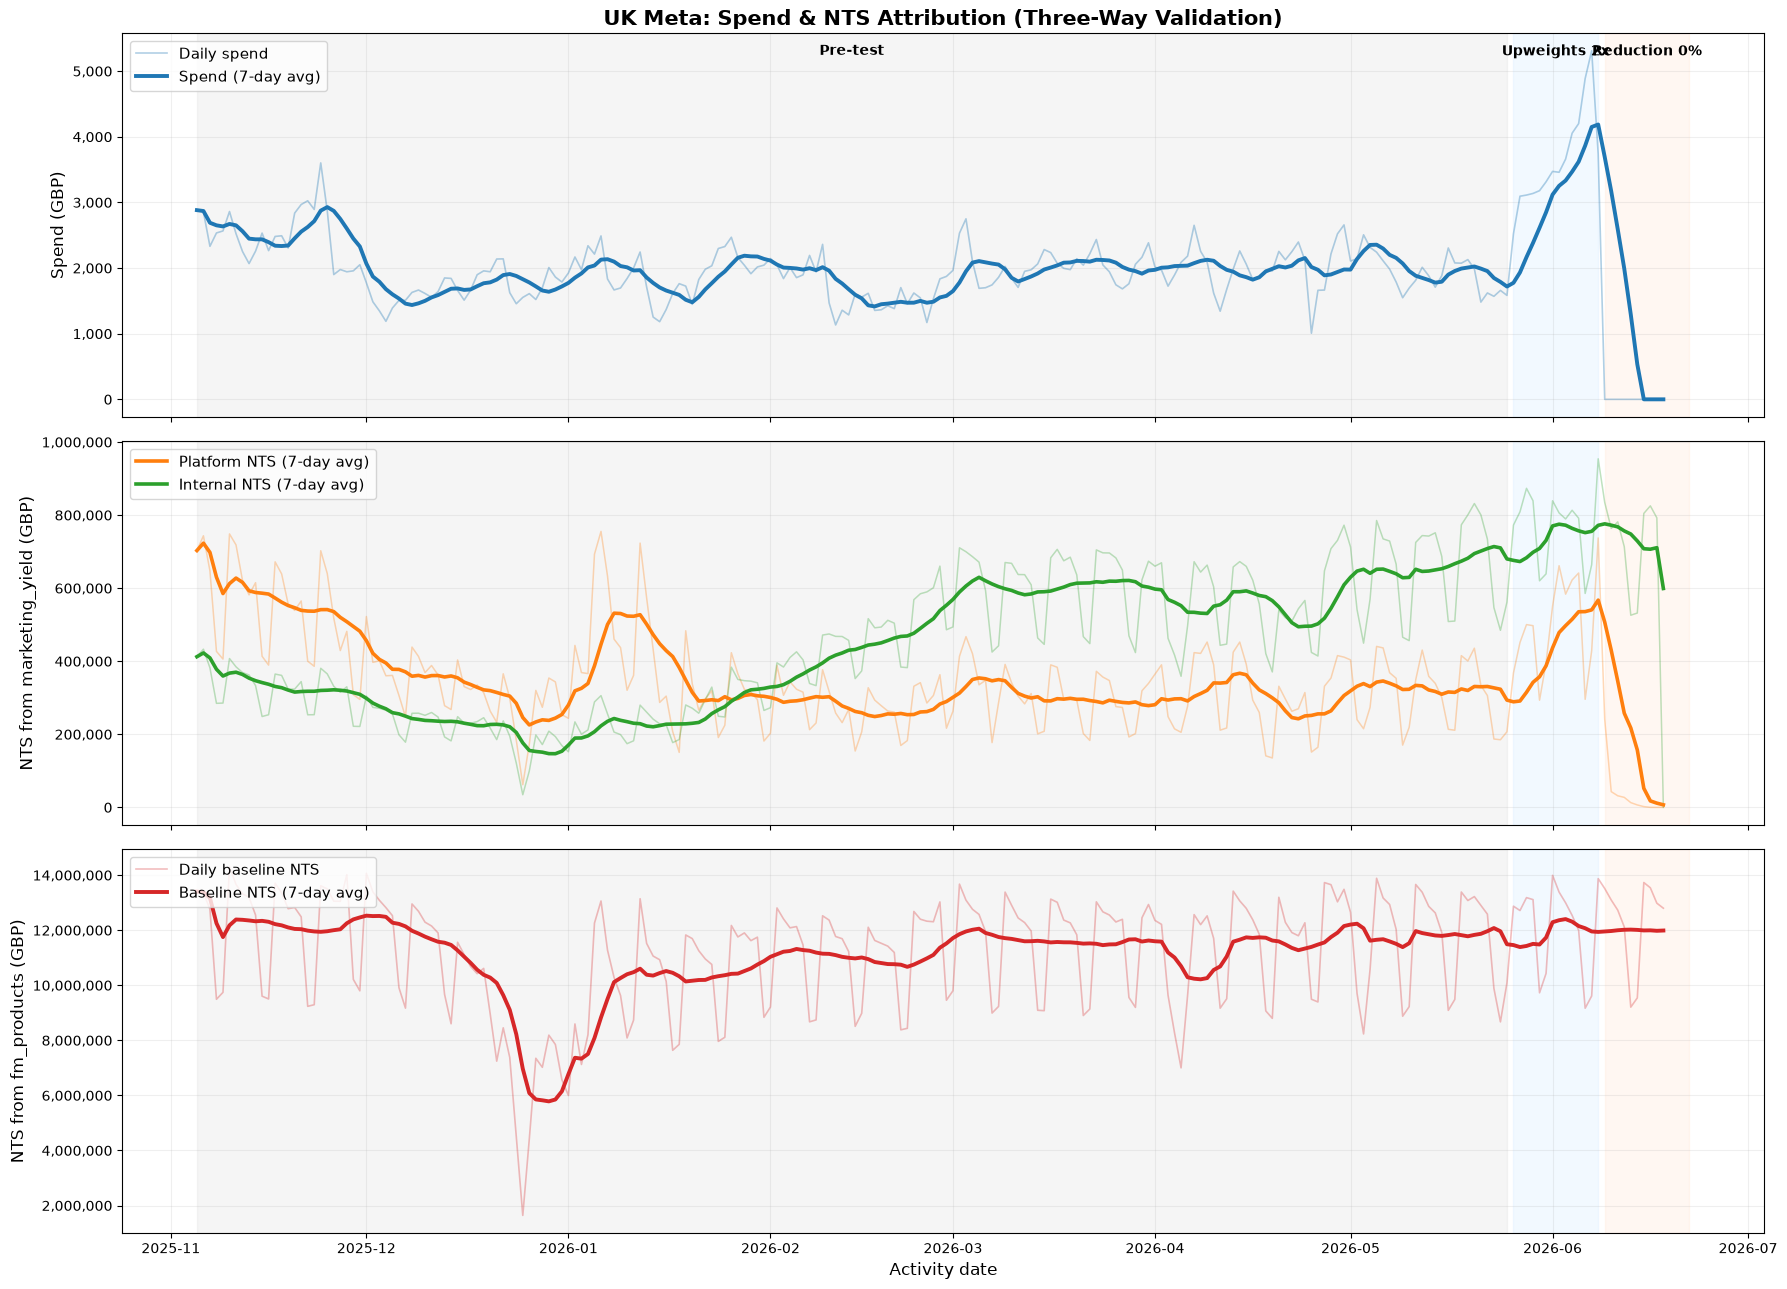


=== Three-Way NTS Validation by Phase ===

       phase  days  total_spend_gbp  platform_nts_gbp  internal_nts_gbp  baseline_nts_gbp  platform_vs_internal_gap_pct
    Pre-test   202           395037          70133280          87913449        2234250863                         -20.2
Upweights 2x    14            51142           7027398          10797616         169605745                         -34.9
Reduction 0%    10                0            364603           6574032         123269432                         -94.5

Note: baseline_nts_gbp is the ground-truth all-demand NTS.
If baseline doesn't move proportionally with spend in upweight phase, the spend may not be incremental.


In [40]:
# Create clearer three-panel visualization
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# Use full GBP values with thousands separators (no scientific notation)
gbp_fmt = FuncFormatter(lambda x, _: f"{int(x):,}")

plot_cols = ['spend_gbp', 'platform_nts', 'internal_nts', 'baseline_nts_gbp']
for col in plot_cols:
    nts_plot_df[col] = pd.to_numeric(nts_plot_df[col], errors='coerce').fillna(0)

# 7-day rolling means for smoother trend visibility
plot_view = nts_plot_df.copy()
plot_view['spend_gbp_7d'] = plot_view['spend_gbp'].rolling(7, min_periods=1).mean()
plot_view['platform_nts_7d'] = plot_view['platform_nts'].rolling(7, min_periods=1).mean()
plot_view['internal_nts_7d'] = plot_view['internal_nts'].rolling(7, min_periods=1).mean()
plot_view['baseline_nts_7d'] = plot_view['baseline_nts_gbp'].rolling(7, min_periods=1).mean()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# Panel 1: Spend
ax1.plot(plot_view['activity_date'], plot_view['spend_gbp'], color='tab:blue', linewidth=1.2, alpha=0.35, label='Daily spend')
ax1.plot(plot_view['activity_date'], plot_view['spend_gbp_7d'], color='tab:blue', linewidth=2.8, label='Spend (7-day avg)')
ax1.set_ylabel('Spend (GBP)', fontsize=12)
ax1.set_title('UK Meta: Spend & NTS Attribution (Three-Way Validation)', fontsize=15, fontweight='bold')
ax1.grid(alpha=0.2)
ax1.yaxis.set_major_formatter(gbp_fmt)
ax1.legend(loc='upper left', fontsize=11)

# Panel 2: Platform vs Internal NTS (marketing_yield)
ax2.plot(plot_view['activity_date'], plot_view['platform_nts'], color='tab:orange', linewidth=1.1, alpha=0.3)
ax2.plot(plot_view['activity_date'], plot_view['internal_nts'], color='tab:green', linewidth=1.1, alpha=0.3)
ax2.plot(plot_view['activity_date'], plot_view['platform_nts_7d'], color='tab:orange', linewidth=2.6, label='Platform NTS (7-day avg)')
ax2.plot(plot_view['activity_date'], plot_view['internal_nts_7d'], color='tab:green', linewidth=2.6, label='Internal NTS (7-day avg)')
ax2.set_ylabel('NTS from marketing_yield (GBP)', fontsize=12)
ax2.grid(alpha=0.2)
ax2.yaxis.set_major_formatter(gbp_fmt)
ax2.legend(loc='upper left', fontsize=11)

# Panel 3: Baseline NTS (fm_products) ground truth
ax3.plot(plot_view['activity_date'], plot_view['baseline_nts_gbp'], color='tab:red', linewidth=1.2, alpha=0.3, label='Daily baseline NTS')
ax3.plot(plot_view['activity_date'], plot_view['baseline_nts_7d'], color='tab:red', linewidth=2.8, label='Baseline NTS (7-day avg)')
ax3.set_ylabel('NTS from fm_products (GBP)', fontsize=12)
ax3.set_xlabel('Activity date', fontsize=12)
ax3.grid(alpha=0.2)
ax3.yaxis.set_major_formatter(gbp_fmt)
ax3.legend(loc='upper left', fontsize=11)

# Shade test phases on all panels
phase_windows = [
    ('Pre-test', PRE_TEST_START, PRE_TEST_END, '#d9d9d9'),
    ('Upweights 2x', UPWEIGHT_START, UPWEIGHT_END, '#cfe8ff'),
    ('Reduction 0%', REDUCTION_START, REDUCTION_END, '#ffe0cc'),
]

for ax in (ax1, ax2, ax3):
    for phase_name, start_dt, end_dt, color in phase_windows:
        ax.axvspan(start_dt, end_dt, color=color, alpha=0.25)

# Add phase labels on top panel
y_top = ax1.get_ylim()[1]
for phase_name, start_dt, end_dt, _ in phase_windows:
    mid = start_dt + (end_dt - start_dt) / 2
    ax1.text(mid, y_top * 0.97, phase_name, ha='center', va='top', fontsize=10, fontweight='bold')

# Better x-axis date formatting
ax3.xaxis.set_major_locator(mdates.MonthLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax3.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Phase-level NTS summary (three metrics)
print("\n=== Three-Way NTS Validation by Phase ===\n")
summary_rows = []
for phase_name, start_dt, end_dt, _ in phase_windows:
    phase_data = nts_plot_df[(nts_plot_df['activity_date'] >= start_dt) & (nts_plot_df['activity_date'] <= end_dt)]
    total_spend = int(phase_data['spend_gbp'].sum())
    platform_nts = int(phase_data['platform_nts'].sum())
    internal_nts = int(phase_data['internal_nts'].sum())
    baseline_nts = int(phase_data['baseline_nts_gbp'].sum())

    summary_rows.append({
        'phase': phase_name,
        'days': int(phase_data['activity_date'].nunique()),
        'total_spend_gbp': total_spend,
        'platform_nts_gbp': platform_nts,
        'internal_nts_gbp': internal_nts,
        'baseline_nts_gbp': baseline_nts,
        'platform_vs_internal_gap_pct': round((platform_nts - internal_nts) / max(internal_nts, 1) * 100, 1),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
print("\nNote: baseline_nts_gbp is the ground-truth all-demand NTS.")
print("If baseline doesn't move proportionally with spend in upweight phase, the spend may not be incremental.")

## On advice of Tom, it seems like that was the wrong way to go about platform NTS. Now going to check marketing campaigns

In [46]:
# Facebook Web attribution from marketing_campaigns (platform-attributed metrics)
# Includes explicit mapping used in Tom's queries:
# - dweb/mweb => web
# - facebook campaigns containing daps => web fallback

facebook_web_platform_sql = """
WITH classified AS (
    SELECT
        DATE(activity_date) AS activity_date,
        region,
        source_system,
        campaign,
        LOWER(device_group) AS device_group,
        cost_gbp,
        platform_conversions_nc,
        platform_conversions_trx_value_gbp,
        CASE
            WHEN LOWER(device_group) IN ('dweb', 'mweb') THEN 'web'
            WHEN LOWER(device_group) IN ('ios', 'android') THEN 'app'
            WHEN LOWER(campaign) LIKE '%daps%' AND LOWER(source_system) = 'facebook' THEN 'web'
            ELSE 'unknown'
        END AS device_bucket
    FROM bi_dwh.marketing_campaigns
    WHERE DATE(activity_date) >= DATE '2025-11-05'
      AND region = 'United Kingdom'
      AND LOWER(source_system) = 'facebook'
)
SELECT
    activity_date,
    SUM(cost_gbp) AS spend_gbp,
    SUM(platform_conversions_trx_value_gbp) AS platform_nts_gbp,
    SUM(platform_conversions_nc) AS platform_ncs,
    SUM(platform_conversions_trx_value_gbp) / NULLIF(SUM(cost_gbp), 0) AS platform_roas,
    SUM(cost_gbp) / NULLIF(SUM(platform_conversions_nc), 0) AS platform_cpa
FROM classified
WHERE device_bucket = 'web'
GROUP BY 1
ORDER BY 1
"""

In [47]:
facebook_web_platform_df = pd.read_sql(facebook_web_platform_sql, conn)
facebook_web_platform_df

/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_37070/3151271399.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  facebook_web_platform_df = pd.read_sql(facebook_web_platform_sql, conn)


,activity_date,spend_gbp,platform_nts_gbp,platform_ncs,platform_roas,platform_cpa
0,2025-11-05,2882.219999,703044.989999,548.0,243.924818,5.259526
1,2025-11-06,2856.000000,743406.980000,486.0,260.296562,5.876543
2,2025-11-07,2331.380000,647326.449999,519.0,277.658061,4.492062
3,2025-11-08,2534.609999,427014.359998,456.0,168.473398,5.558355
4,2025-11-09,2565.880000,405973.219999,347.0,158.219878,7.394467
...,...,...,...,...,...,...
218,2026-06-11,0.000000,31712.940000,25.0,NaN,0.000000
219,2026-06-12,0.000000,27385.200000,33.0,NaN,0.000000
220,2026-06-13,0.000000,12980.850000,20.0,NaN,0.000000
221,2026-06-14,0.000000,6662.820000,9.0,NaN,0.000000


In [48]:
# Diagnostics: check how Facebook rows are being bucketed into web/app/unknown
facebook_web_diag_sql = """
SELECT
    CASE
        WHEN LOWER(device_group) IN ('dweb', 'mweb') THEN 'web'
        WHEN LOWER(device_group) IN ('ios', 'android') THEN 'app'
        WHEN LOWER(campaign) LIKE '%daps%' AND LOWER(source_system) = 'facebook' THEN 'web'
        ELSE 'unknown'
    END AS device_bucket,
    LOWER(device_group) AS raw_device_group,
    COUNT(*) AS rows,
    SUM(cost_gbp) AS spend_gbp,
    SUM(platform_conversions_trx_value_gbp) AS platform_nts_gbp,
    SUM(platform_conversions_nc) AS platform_ncs
FROM bi_dwh.marketing_campaigns
WHERE DATE(activity_date) >= DATE '2025-11-05'
  AND region = 'United Kingdom'
  AND LOWER(source_system) = 'facebook'
GROUP BY 1,2
ORDER BY 1,2
"""

pd.read_sql(facebook_web_diag_sql, conn)

/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_37070/3653853978.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(facebook_web_diag_sql, conn)


,device_bucket,raw_device_group,rows,spend_gbp,platform_nts_gbp,platform_ncs
0,app,android,1808,165262.199995,7.664629e+06,9814.0
1,app,ios,1451,108610.569900,9.115001e+06,5871.0
2,unknown,unknown,156,4645.889999,9.125390e+05,1055.0
3,web,unknown,8821,446179.479982,7.752528e+07,92585.0


In [49]:
# Optional: stricter Meta campaign-name filter if you want to avoid non-Meta noise in source_system
facebook_web_platform_strict_sql = """
WITH classified AS (
    SELECT
        DATE(activity_date) AS activity_date,
        region,
        source_system,
        campaign,
        LOWER(device_group) AS device_group,
        cost_gbp,
        platform_conversions_nc,
        platform_conversions_trx_value_gbp,
        CASE
            WHEN LOWER(device_group) IN ('dweb', 'mweb') THEN 'web'
            WHEN LOWER(device_group) IN ('ios', 'android') THEN 'app'
            WHEN LOWER(campaign) LIKE '%daps%' AND LOWER(source_system) = 'facebook' THEN 'web'
            ELSE 'unknown'
        END AS device_bucket
    FROM bi_dwh.marketing_campaigns
    WHERE DATE(activity_date) >= DATE '2025-11-05'
      AND region = 'United Kingdom'
      AND LOWER(source_system) = 'facebook'
      AND REGEXP_LIKE(LOWER(campaign), '(^|[_\\-\\s>:])(fb|facebook|ig|instagram|meta)([_\\-\\s:]|$)')
)
SELECT
    activity_date,
    SUM(cost_gbp) AS spend_gbp,
    SUM(platform_conversions_trx_value_gbp) AS platform_nts_gbp,
    SUM(platform_conversions_nc) AS platform_ncs
FROM classified
WHERE device_bucket = 'web'
GROUP BY 1
ORDER BY 1
"""

In [50]:
# Run strict version if needed
facebook_web_platform_strict_df = pd.read_sql(facebook_web_platform_strict_sql, conn)
facebook_web_platform_strict_df

/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_37070/2442834748.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  facebook_web_platform_strict_df = pd.read_sql(facebook_web_platform_strict_sql, conn)


,activity_date,spend_gbp,platform_nts_gbp,platform_ncs
0,2025-11-05,2882.219999,703044.989999,548.0
1,2025-11-06,2856.000000,743406.980000,486.0
2,2025-11-07,2331.380000,647326.449999,519.0
3,2025-11-08,2534.609999,427014.359998,456.0
4,2025-11-09,2565.880000,405973.219999,347.0
...,...,...,...,...
218,2026-06-11,0.000000,31712.940000,25.0
219,2026-06-12,0.000000,27385.200000,33.0
220,2026-06-13,0.000000,12980.850000,20.0
221,2026-06-14,0.000000,6662.820000,9.0


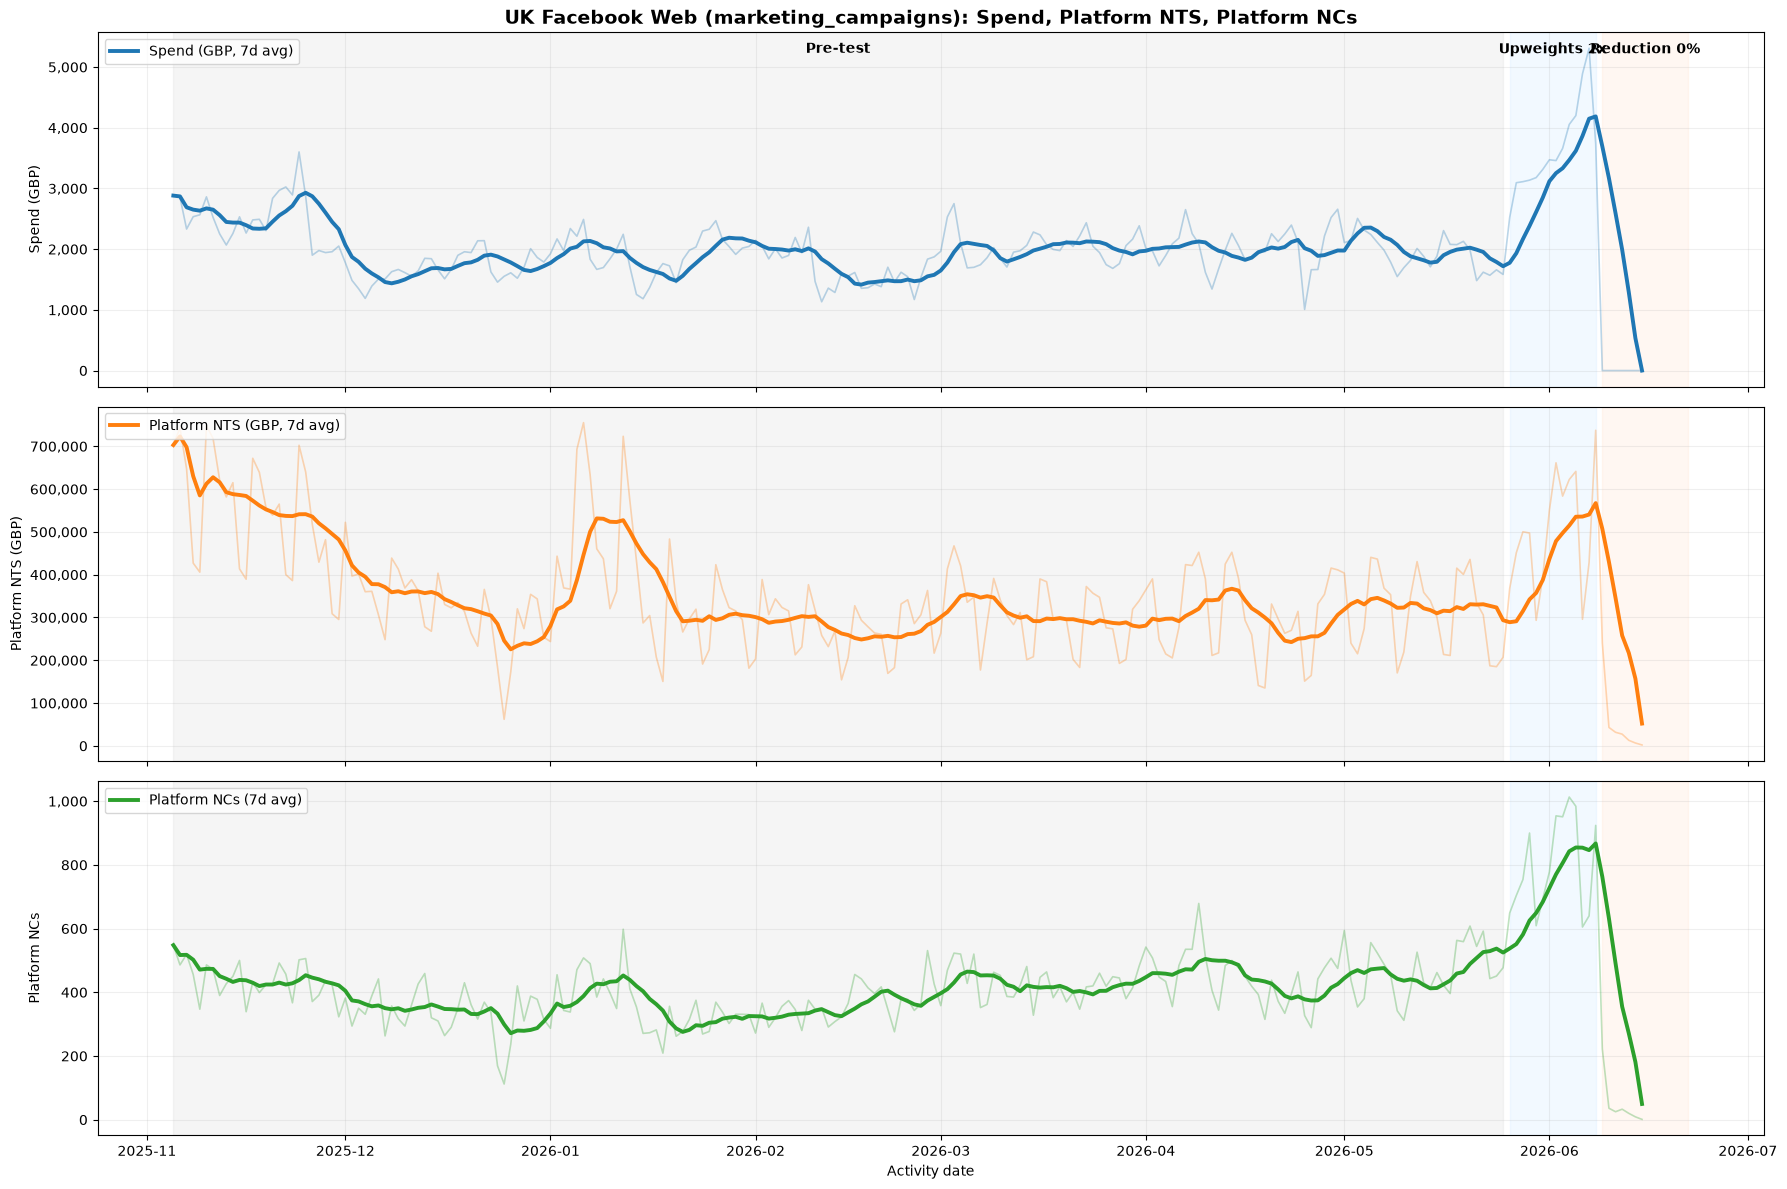

In [51]:
# Plot Facebook Web platform metrics from marketing_campaigns
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

mc_plot_df = facebook_web_platform_df.copy()
mc_plot_df['activity_date'] = pd.to_datetime(mc_plot_df['activity_date'])
mc_plot_df = mc_plot_df.sort_values('activity_date')

for c in ['spend_gbp', 'platform_nts_gbp', 'platform_ncs']:
    mc_plot_df[c] = pd.to_numeric(mc_plot_df[c], errors='coerce').fillna(0)

# 7-day smoothing for readability
mc_plot_df['spend_gbp_7d'] = mc_plot_df['spend_gbp'].rolling(7, min_periods=1).mean()
mc_plot_df['platform_nts_gbp_7d'] = mc_plot_df['platform_nts_gbp'].rolling(7, min_periods=1).mean()
mc_plot_df['platform_ncs_7d'] = mc_plot_df['platform_ncs'].rolling(7, min_periods=1).mean()

fmt_gbp = FuncFormatter(lambda x, _: f"{int(x):,}")
fmt_int = FuncFormatter(lambda x, _: f"{int(x):,}")

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Spend
ax1.plot(mc_plot_df['activity_date'], mc_plot_df['spend_gbp'], color='tab:blue', alpha=0.3, linewidth=1.2)
ax1.plot(mc_plot_df['activity_date'], mc_plot_df['spend_gbp_7d'], color='tab:blue', linewidth=2.8, label='Spend (GBP, 7d avg)')
ax1.set_ylabel('Spend (GBP)')
ax1.yaxis.set_major_formatter(fmt_gbp)
ax1.grid(alpha=0.2)
ax1.legend(loc='upper left')

# Platform NTS
ax2.plot(mc_plot_df['activity_date'], mc_plot_df['platform_nts_gbp'], color='tab:orange', alpha=0.3, linewidth=1.2)
ax2.plot(mc_plot_df['activity_date'], mc_plot_df['platform_nts_gbp_7d'], color='tab:orange', linewidth=2.8, label='Platform NTS (GBP, 7d avg)')
ax2.set_ylabel('Platform NTS (GBP)')
ax2.yaxis.set_major_formatter(fmt_gbp)
ax2.grid(alpha=0.2)
ax2.legend(loc='upper left')

# Platform NCs
ax3.plot(mc_plot_df['activity_date'], mc_plot_df['platform_ncs'], color='tab:green', alpha=0.3, linewidth=1.2)
ax3.plot(mc_plot_df['activity_date'], mc_plot_df['platform_ncs_7d'], color='tab:green', linewidth=2.8, label='Platform NCs (7d avg)')
ax3.set_ylabel('Platform NCs')
ax3.yaxis.set_major_formatter(fmt_int)
ax3.set_xlabel('Activity date')
ax3.grid(alpha=0.2)
ax3.legend(loc='upper left')

# Phase shading
phase_windows = [
    ('Pre-test', PRE_TEST_START, PRE_TEST_END, '#d9d9d9'),
    ('Upweights 2x', UPWEIGHT_START, UPWEIGHT_END, '#cfe8ff'),
    ('Reduction 0%', REDUCTION_START, REDUCTION_END, '#ffe0cc'),
]

for ax in (ax1, ax2, ax3):
    for _, start_dt, end_dt, color in phase_windows:
        ax.axvspan(start_dt, end_dt, color=color, alpha=0.25)

# Phase labels on first panel
y_top = ax1.get_ylim()[1]
for phase_name, start_dt, end_dt, _ in phase_windows:
    mid = start_dt + (end_dt - start_dt) / 2
    ax1.text(mid, y_top * 0.97, phase_name, ha='center', va='top', fontsize=10, fontweight='bold')

ax1.set_title('UK Facebook Web (marketing_campaigns): Spend, Platform NTS, Platform NCs', fontsize=14, fontweight='bold')
ax3.xaxis.set_major_locator(mdates.MonthLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

In [52]:
# Phase summary for Facebook Web platform metrics
mc_phase_rows = []
for phase_name, start_dt, end_dt, _ in phase_windows:
    p = mc_plot_df[(mc_plot_df['activity_date'] >= start_dt) & (mc_plot_df['activity_date'] <= end_dt)]
    spend = float(p['spend_gbp'].sum())
    nts = float(p['platform_nts_gbp'].sum())
    ncs = float(p['platform_ncs'].sum())
    mc_phase_rows.append({
        'phase': phase_name,
        'days': int(p['activity_date'].nunique()),
        'spend_gbp': int(round(spend, 0)),
        'platform_nts_gbp': int(round(nts, 0)),
        'platform_ncs': int(round(ncs, 0)),
        'platform_roas': round(nts / spend, 2) if spend > 0 else np.nan,
        'platform_cpa': round(spend / ncs, 2) if ncs > 0 else np.nan,
    })

mc_phase_summary_df = pd.DataFrame(mc_phase_rows)
print('\n=== Facebook Web Platform Metrics by Phase ===\n')
mc_phase_summary_df


=== Facebook Web Platform Metrics by Phase ===



,phase,days,spend_gbp,platform_nts_gbp,platform_ncs,platform_roas,platform_cpa
0,Pre-test,202,395037,70133280,81080,177.54,4.87
1,Upweights 2x,14,51142,7027399,11159,137.41,4.58
2,Reduction 0%,7,0,364604,346,NaN,0.00


In [53]:
# Optional check: base vs strict query totals should be very close
base_totals = facebook_web_platform_df[['spend_gbp', 'platform_nts_gbp', 'platform_ncs']].sum(numeric_only=True)
strict_totals = facebook_web_platform_strict_df[['spend_gbp', 'platform_nts_gbp', 'platform_ncs']].sum(numeric_only=True)

comparison = pd.DataFrame({'base': base_totals, 'strict': strict_totals})
comparison['diff'] = comparison['base'] - comparison['strict']
comparison['diff_pct'] = np.where(comparison['strict'] != 0, comparison['diff'] / comparison['strict'] * 100, np.nan)
comparison

,base,strict,diff,diff_pct
spend_gbp,4.461795e+05,4.461795e+05,0.0,0.0
platform_nts_gbp,7.752528e+07,7.752528e+07,0.0,0.0
platform_ncs,9.258500e+04,9.258500e+04,0.0,0.0


In [58]:
# Platform vs Internal comparison (NCs + NTS)
# Platform metrics come ONLY from marketing_campaigns
# Internal metrics come from marketing_yield
platform_internal_nc_nts_sql = """
WITH platform_campaigns AS (
    SELECT
        DATE(activity_date) AS activity_date,
        SUM(platform_conversions_trx_value_gbp) AS platform_nts_gbp,
        SUM(platform_conversions_nc) AS platform_ncs
    FROM bi_dwh.marketing_campaigns
    WHERE DATE(activity_date) >= DATE '2025-11-05'
      AND region = 'United Kingdom'
      AND LOWER(source_system) = 'facebook'
      AND (
            LOWER(device_group) IN ('dweb', 'mweb')
            OR (LOWER(device_group) = 'unknown' AND LOWER(campaign) LIKE '%daps%')
          )
    GROUP BY 1
),
internal_yield AS (
    SELECT
        DATE(activity_date) AS activity_date,
        SUM(total_gross_sales_gbp) AS internal_nts_gbp,
        SUM(new_customer_count) AS internal_ncs
    FROM bi_dwh.marketing_yield
    WHERE original_attribution = FALSE
      AND region = 'United Kingdom'
      AND DATE(activity_date) >= DATE '2025-11-05'
      AND channel_0 = 'Web - Paid Social'
      AND channel_2 = 'Facebook'
    GROUP BY 1
)
SELECT
    COALESCE(i.activity_date, p.activity_date) AS activity_date,
    COALESCE(i.internal_nts_gbp, 0) AS internal_nts_gbp,
    COALESCE(p.platform_nts_gbp, 0) AS platform_nts_gbp,
    COALESCE(i.internal_ncs, 0) AS internal_ncs,
    COALESCE(p.platform_ncs, 0) AS platform_ncs
FROM internal_yield i
FULL OUTER JOIN platform_campaigns p
    ON i.activity_date = p.activity_date
ORDER BY 1
"""

In [59]:
platform_internal_nc_nts_df = pd.read_sql(platform_internal_nc_nts_sql, conn)
platform_internal_nc_nts_df['activity_date'] = pd.to_datetime(platform_internal_nc_nts_df['activity_date'])
platform_internal_nc_nts_df = platform_internal_nc_nts_df.sort_values('activity_date')

for c in ['internal_nts_gbp', 'platform_nts_gbp', 'internal_ncs', 'platform_ncs']:
    platform_internal_nc_nts_df[c] = pd.to_numeric(platform_internal_nc_nts_df[c], errors='coerce').fillna(0)

# Smooth for easier trend reading
for c in ['internal_nts_gbp', 'platform_nts_gbp', 'internal_ncs', 'platform_ncs']:
    platform_internal_nc_nts_df[f'{c}_7d'] = platform_internal_nc_nts_df[c].rolling(7, min_periods=1).mean()

platform_internal_nc_nts_df.head()

/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_37070/1210531129.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  platform_internal_nc_nts_df = pd.read_sql(platform_internal_nc_nts_sql, conn)


,activity_date,internal_nts_gbp,platform_nts_gbp,internal_ncs,platform_ncs,internal_nts_gbp_7d,platform_nts_gbp_7d,internal_ncs_7d,platform_ncs_7d
0,2025-11-05,412447.952987,703044.989999,158.0,548.0,412447.952987,703044.989999,158.0,548.000000
1,2025-11-06,433038.938168,743406.980000,143.0,486.0,422743.445577,723225.984999,150.5,517.000000
2,2025-11-07,381964.505067,647326.449999,167.0,519.0,409150.465407,697926.139999,156.0,517.666667
3,2025-11-08,284820.270892,427014.359998,166.0,456.0,378067.916779,630198.194999,158.5,502.250000
4,2025-11-09,285522.961136,405973.219999,108.0,347.0,359558.925650,585353.199999,148.4,471.200000


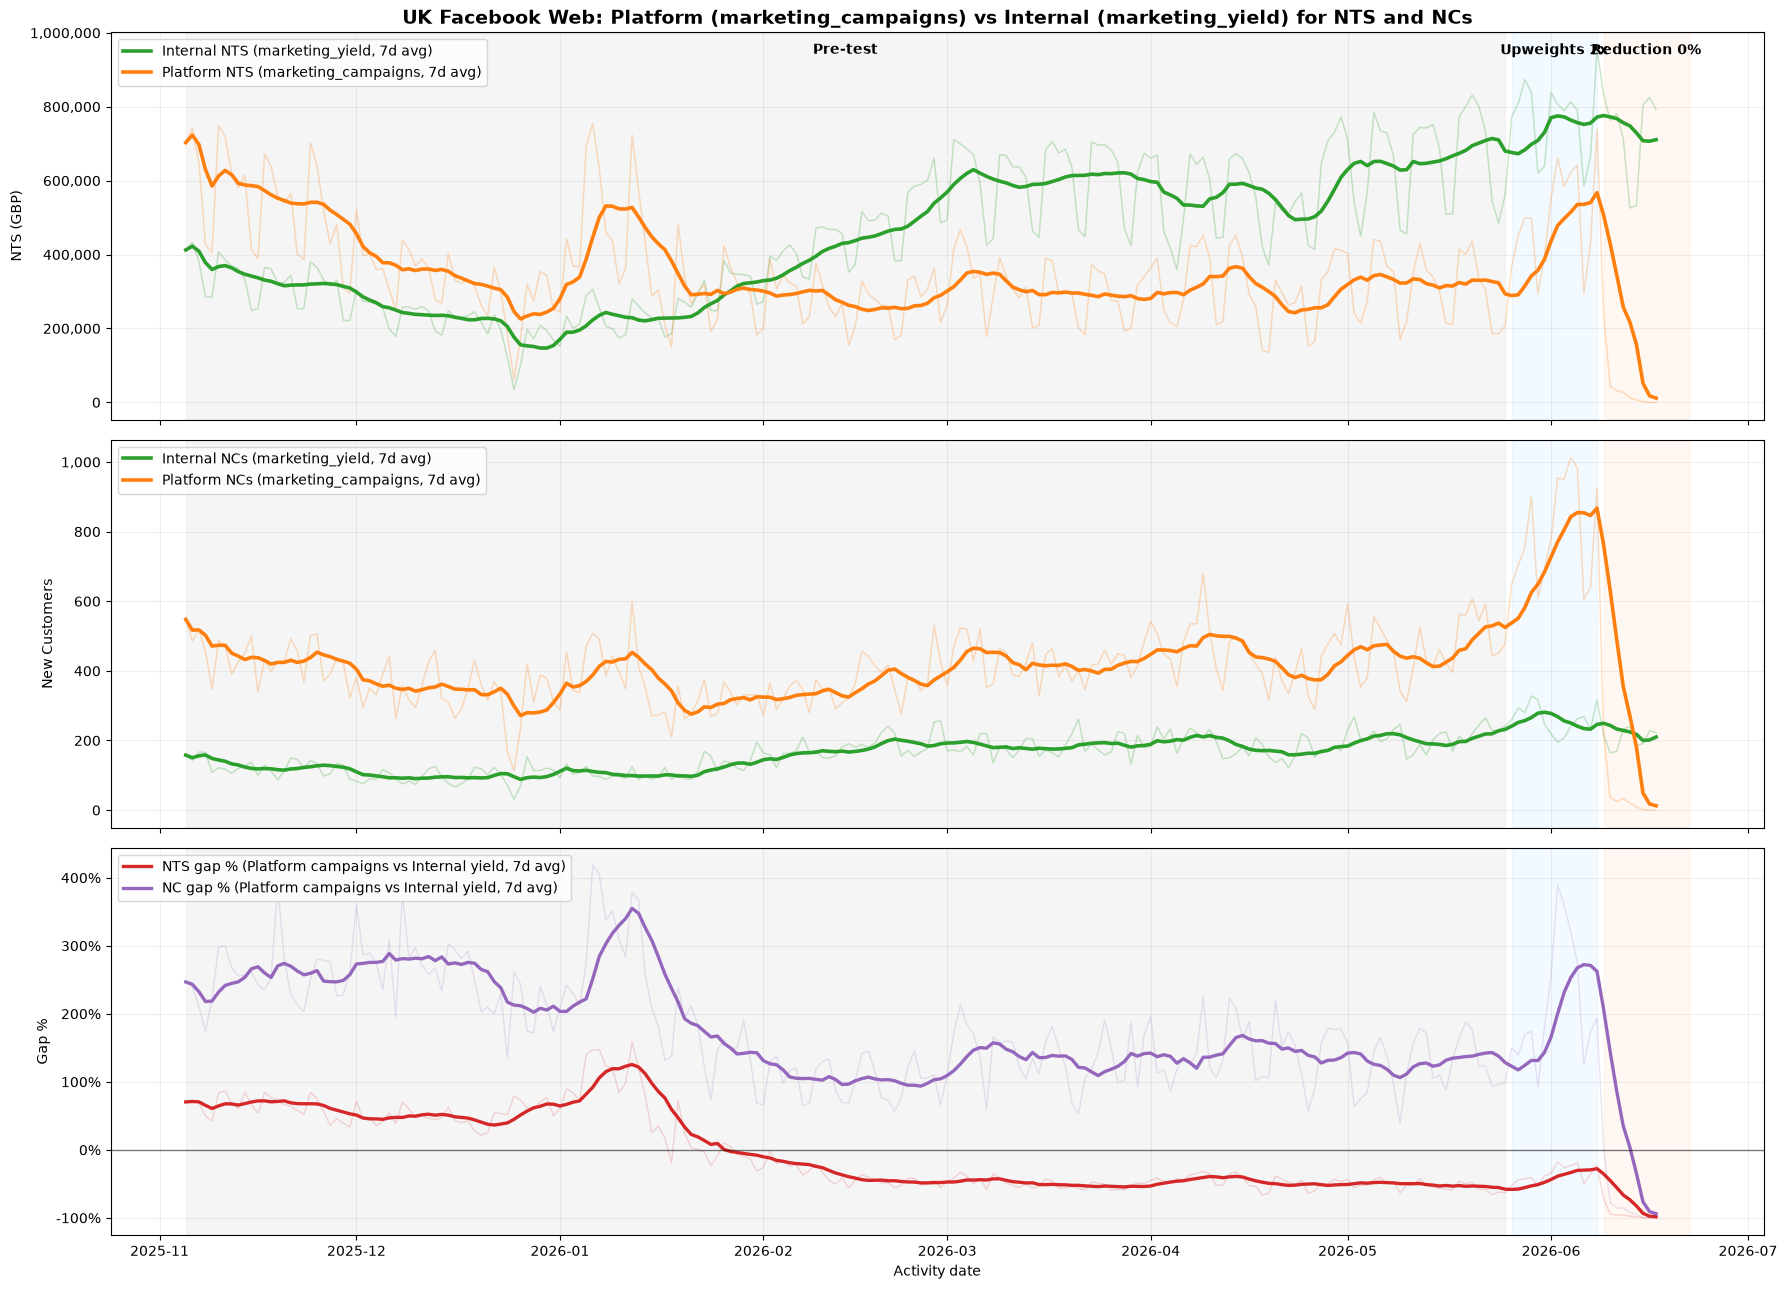

In [60]:
# Plot platform vs internal for NTS and NCs, plus % gap lines
# Platform source: marketing_campaigns | Internal source: marketing_yield
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates

fmt_gbp = FuncFormatter(lambda x, _: f"{int(x):,}")
fmt_int = FuncFormatter(lambda x, _: f"{int(x):,}")
fmt_pct = FuncFormatter(lambda x, _: f"{x:.0f}%")

cmp_df = platform_internal_nc_nts_df.copy()
cmp_df['nts_gap_pct'] = np.where(cmp_df['internal_nts_gbp'] > 0, (cmp_df['platform_nts_gbp'] - cmp_df['internal_nts_gbp']) / cmp_df['internal_nts_gbp'] * 100, np.nan)
cmp_df['ncs_gap_pct'] = np.where(cmp_df['internal_ncs'] > 0, (cmp_df['platform_ncs'] - cmp_df['internal_ncs']) / cmp_df['internal_ncs'] * 100, np.nan)
cmp_df['nts_gap_pct_7d'] = cmp_df['nts_gap_pct'].rolling(7, min_periods=1).mean()
cmp_df['ncs_gap_pct_7d'] = cmp_df['ncs_gap_pct'].rolling(7, min_periods=1).mean()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# NTS panel
ax1.plot(cmp_df['activity_date'], cmp_df['internal_nts_gbp'], color='tab:green', alpha=0.25, linewidth=1.1)
ax1.plot(cmp_df['activity_date'], cmp_df['platform_nts_gbp'], color='tab:orange', alpha=0.25, linewidth=1.1)
ax1.plot(cmp_df['activity_date'], cmp_df['internal_nts_gbp_7d'], color='tab:green', linewidth=2.6, label='Internal NTS (marketing_yield, 7d avg)')
ax1.plot(cmp_df['activity_date'], cmp_df['platform_nts_gbp_7d'], color='tab:orange', linewidth=2.6, label='Platform NTS (marketing_campaigns, 7d avg)')
ax1.set_ylabel('NTS (GBP)')
ax1.yaxis.set_major_formatter(fmt_gbp)
ax1.grid(alpha=0.2)
ax1.legend(loc='upper left')

# NC panel
ax2.plot(cmp_df['activity_date'], cmp_df['internal_ncs'], color='tab:green', alpha=0.25, linewidth=1.1)
ax2.plot(cmp_df['activity_date'], cmp_df['platform_ncs'], color='tab:orange', alpha=0.25, linewidth=1.1)
ax2.plot(cmp_df['activity_date'], cmp_df['internal_ncs_7d'], color='tab:green', linewidth=2.6, label='Internal NCs (marketing_yield, 7d avg)')
ax2.plot(cmp_df['activity_date'], cmp_df['platform_ncs_7d'], color='tab:orange', linewidth=2.6, label='Platform NCs (marketing_campaigns, 7d avg)')
ax2.set_ylabel('New Customers')
ax2.yaxis.set_major_formatter(fmt_int)
ax2.grid(alpha=0.2)
ax2.legend(loc='upper left')

# Gap panel
ax3.plot(cmp_df['activity_date'], cmp_df['nts_gap_pct'], color='tab:red', alpha=0.18, linewidth=1.0)
ax3.plot(cmp_df['activity_date'], cmp_df['ncs_gap_pct'], color='tab:purple', alpha=0.18, linewidth=1.0)
ax3.plot(cmp_df['activity_date'], cmp_df['nts_gap_pct_7d'], color='tab:red', linewidth=2.4, label='NTS gap % (Platform campaigns vs Internal yield, 7d avg)')
ax3.plot(cmp_df['activity_date'], cmp_df['ncs_gap_pct_7d'], color='tab:purple', linewidth=2.4, label='NC gap % (Platform campaigns vs Internal yield, 7d avg)')
ax3.axhline(0, color='black', linewidth=1, alpha=0.5)
ax3.set_ylabel('Gap %')
ax3.yaxis.set_major_formatter(fmt_pct)
ax3.set_xlabel('Activity date')
ax3.grid(alpha=0.2)
ax3.legend(loc='upper left')

phase_windows = [
    ('Pre-test', PRE_TEST_START, PRE_TEST_END, '#d9d9d9'),
    ('Upweights 2x', UPWEIGHT_START, UPWEIGHT_END, '#cfe8ff'),
    ('Reduction 0%', REDUCTION_START, REDUCTION_END, '#ffe0cc'),
]

for ax in (ax1, ax2, ax3):
    for _, start_dt, end_dt, color in phase_windows:
        ax.axvspan(start_dt, end_dt, color=color, alpha=0.25)

y_top = ax1.get_ylim()[1]
for phase_name, start_dt, end_dt, _ in phase_windows:
    mid = start_dt + (end_dt - start_dt) / 2
    ax1.text(mid, y_top * 0.97, phase_name, ha='center', va='top', fontsize=10, fontweight='bold')

ax1.set_title('UK Facebook Web: Platform (marketing_campaigns) vs Internal (marketing_yield) for NTS and NCs', fontsize=14, fontweight='bold')
ax3.xaxis.set_major_locator(mdates.MonthLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

In [61]:
# Phase summary for platform vs internal NTS and NCs
pi_phase_rows = []
for phase_name, start_dt, end_dt, _ in phase_windows:
    p = cmp_df[(cmp_df['activity_date'] >= start_dt) & (cmp_df['activity_date'] <= end_dt)]

    internal_nts = float(p['internal_nts_gbp'].sum())
    platform_nts = float(p['platform_nts_gbp'].sum())
    internal_ncs = float(p['internal_ncs'].sum())
    platform_ncs = float(p['platform_ncs'].sum())

    pi_phase_rows.append({
        'phase': phase_name,
        'days': int(p['activity_date'].nunique()),
        'internal_nts_gbp': int(round(internal_nts, 0)),
        'platform_nts_gbp': int(round(platform_nts, 0)),
        'nts_gap_pct': round(((platform_nts - internal_nts) / internal_nts * 100) if internal_nts > 0 else np.nan, 1),
        'internal_ncs': int(round(internal_ncs, 0)),
        'platform_ncs': int(round(platform_ncs, 0)),
        'ncs_gap_pct': round(((platform_ncs - internal_ncs) / internal_ncs * 100) if internal_ncs > 0 else np.nan, 1),
    })

pi_phase_summary_df = pd.DataFrame(pi_phase_rows)
print('\n=== Platform vs Internal (NTS + NCs) by Phase ===\n')
pi_phase_summary_df


=== Platform vs Internal (NTS + NCs) by Phase ===



,phase,days,internal_nts_gbp,platform_nts_gbp,nts_gap_pct,internal_ncs,platform_ncs,ncs_gap_pct
0,Pre-test,202,87913450,70133280,-20.2,31335,81080,158.8
1,Upweights 2x,14,10797617,7027399,-34.9,3668,11159,204.2
2,Reduction 0%,9,6574032,364604,-94.5,1852,346,-81.3


/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_37070/2407604164.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  platform_internal_orders_df = pd.read_sql(platform_internal_orders_sql, conn)


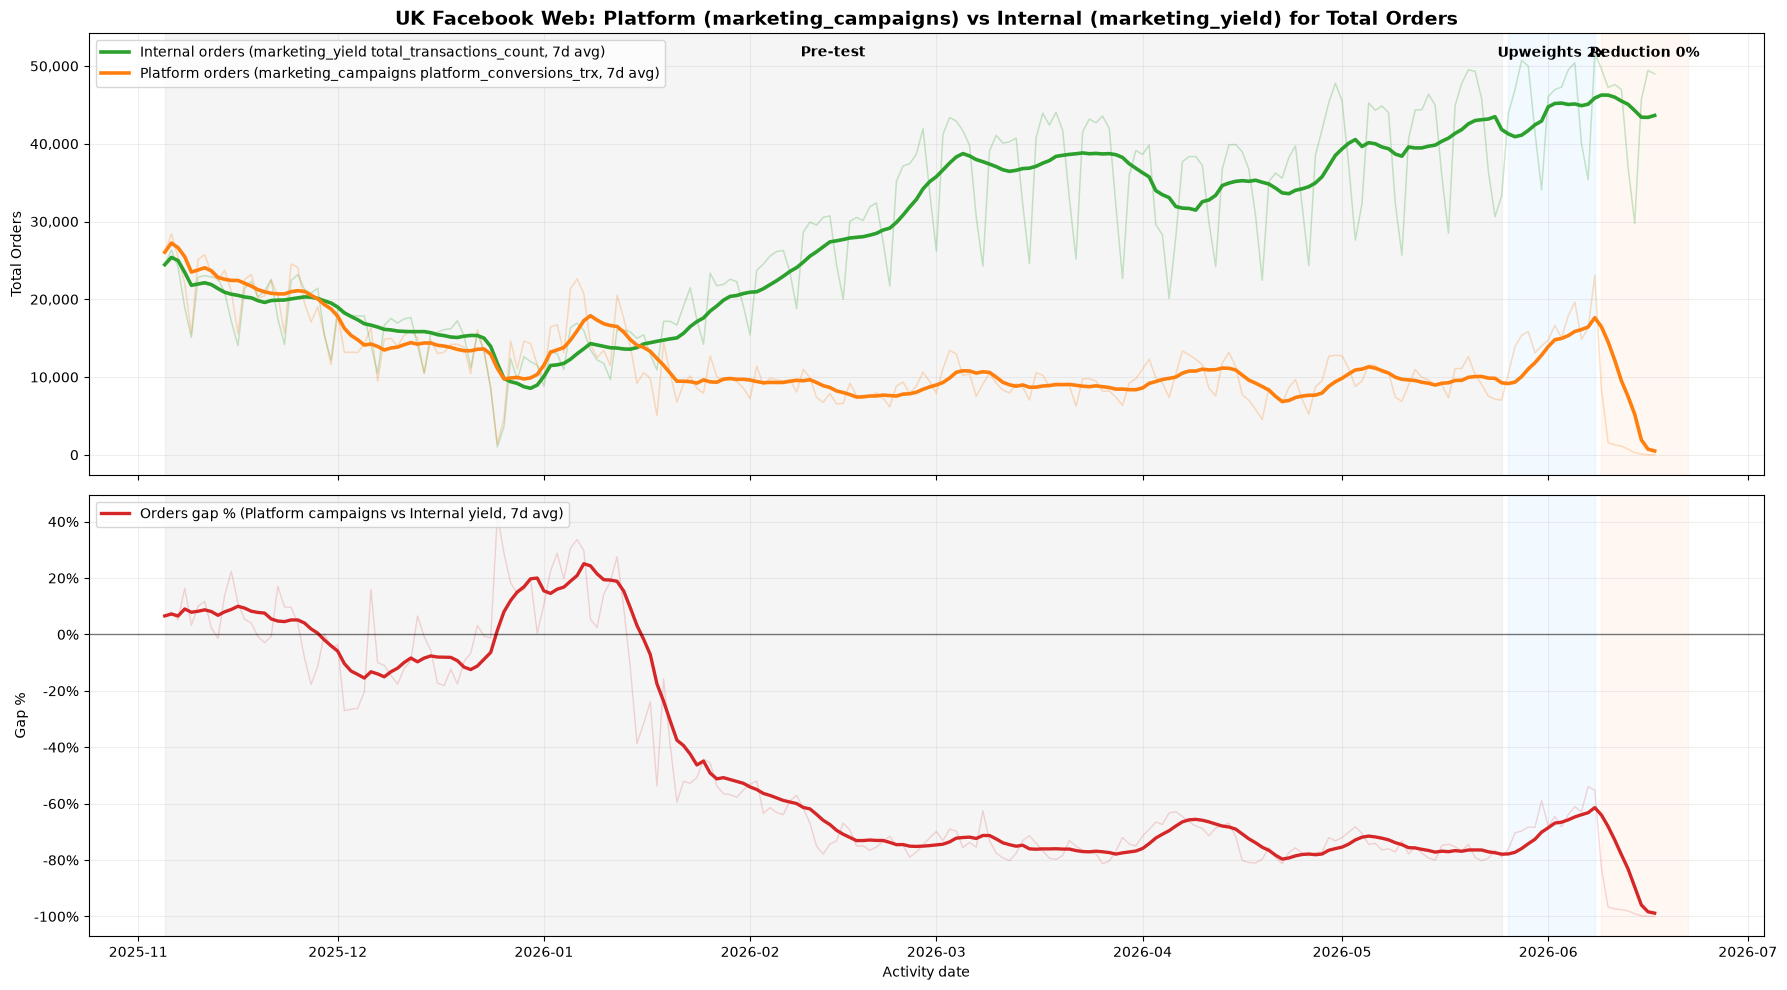


=== Platform vs Internal (Total Orders) by Phase ===



,phase,days,internal_orders,platform_orders,orders_gap_pct
0,Pre-test,202,5480704,2388240,-56.4
1,Upweights 2x,14,634397,220794,-65.2
2,Reduction 0%,9,402323,13486,-96.6


In [62]:
# Platform vs Internal comparison (Total Orders / marketing_orders)
# Platform orders come ONLY from marketing_campaigns
# Internal orders come from marketing_yield (total_transactions_count)
platform_internal_orders_sql = """
WITH platform_campaigns AS (
    SELECT
        DATE(activity_date) AS activity_date,
        SUM(platform_conversions_trx) AS platform_orders
    FROM bi_dwh.marketing_campaigns
    WHERE DATE(activity_date) >= DATE '2025-11-05'
      AND region = 'United Kingdom'
      AND LOWER(source_system) = 'facebook'
      AND (
            LOWER(device_group) IN ('dweb', 'mweb')
            OR (LOWER(device_group) = 'unknown' AND LOWER(campaign) LIKE '%daps%')
          )
    GROUP BY 1
),
internal_yield AS (
    SELECT
        DATE(activity_date) AS activity_date,
        SUM(total_transactions_count) AS internal_orders
    FROM bi_dwh.marketing_yield
    WHERE original_attribution = FALSE
      AND region = 'United Kingdom'
      AND DATE(activity_date) >= DATE '2025-11-05'
      AND channel_0 = 'Web - Paid Social'
      AND channel_2 = 'Facebook'
    GROUP BY 1
)
SELECT
    COALESCE(i.activity_date, p.activity_date) AS activity_date,
    COALESCE(i.internal_orders, 0) AS internal_orders,
    COALESCE(p.platform_orders, 0) AS platform_orders
FROM internal_yield i
FULL OUTER JOIN platform_campaigns p
    ON i.activity_date = p.activity_date
ORDER BY 1
"""

platform_internal_orders_df = pd.read_sql(platform_internal_orders_sql, conn)
platform_internal_orders_df['activity_date'] = pd.to_datetime(platform_internal_orders_df['activity_date'])
platform_internal_orders_df = platform_internal_orders_df.sort_values('activity_date')

for c in ['internal_orders', 'platform_orders']:
    platform_internal_orders_df[c] = pd.to_numeric(platform_internal_orders_df[c], errors='coerce').fillna(0)
    platform_internal_orders_df[f'{c}_7d'] = platform_internal_orders_df[c].rolling(7, min_periods=1).mean()

orders_cmp_df = platform_internal_orders_df.copy()
orders_cmp_df['orders_gap_pct'] = np.where(
    orders_cmp_df['internal_orders'] > 0,
    (orders_cmp_df['platform_orders'] - orders_cmp_df['internal_orders']) / orders_cmp_df['internal_orders'] * 100,
    np.nan,
)
orders_cmp_df['orders_gap_pct_7d'] = orders_cmp_df['orders_gap_pct'].rolling(7, min_periods=1).mean()

fmt_int = FuncFormatter(lambda x, _: f"{int(x):,}")
fmt_pct = FuncFormatter(lambda x, _: f"{x:.0f}%")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Orders panel
ax1.plot(orders_cmp_df['activity_date'], orders_cmp_df['internal_orders'], color='tab:green', alpha=0.25, linewidth=1.1)
ax1.plot(orders_cmp_df['activity_date'], orders_cmp_df['platform_orders'], color='tab:orange', alpha=0.25, linewidth=1.1)
ax1.plot(orders_cmp_df['activity_date'], orders_cmp_df['internal_orders_7d'], color='tab:green', linewidth=2.6, label='Internal orders (marketing_yield total_transactions_count, 7d avg)')
ax1.plot(orders_cmp_df['activity_date'], orders_cmp_df['platform_orders_7d'], color='tab:orange', linewidth=2.6, label='Platform orders (marketing_campaigns platform_conversions_trx, 7d avg)')
ax1.set_ylabel('Total Orders')
ax1.yaxis.set_major_formatter(fmt_int)
ax1.grid(alpha=0.2)
ax1.legend(loc='upper left')

# Gap panel
ax2.plot(orders_cmp_df['activity_date'], orders_cmp_df['orders_gap_pct'], color='tab:red', alpha=0.18, linewidth=1.0)
ax2.plot(orders_cmp_df['activity_date'], orders_cmp_df['orders_gap_pct_7d'], color='tab:red', linewidth=2.4, label='Orders gap % (Platform campaigns vs Internal yield, 7d avg)')
ax2.axhline(0, color='black', linewidth=1, alpha=0.5)
ax2.set_ylabel('Gap %')
ax2.yaxis.set_major_formatter(fmt_pct)
ax2.set_xlabel('Activity date')
ax2.grid(alpha=0.2)
ax2.legend(loc='upper left')

phase_windows = [
    ('Pre-test', PRE_TEST_START, PRE_TEST_END, '#d9d9d9'),
    ('Upweights 2x', UPWEIGHT_START, UPWEIGHT_END, '#cfe8ff'),
    ('Reduction 0%', REDUCTION_START, REDUCTION_END, '#ffe0cc'),
]

for ax in (ax1, ax2):
    for _, start_dt, end_dt, color in phase_windows:
        ax.axvspan(start_dt, end_dt, color=color, alpha=0.25)

y_top = ax1.get_ylim()[1]
for phase_name, start_dt, end_dt, _ in phase_windows:
    mid = start_dt + (end_dt - start_dt) / 2
    ax1.text(mid, y_top * 0.97, phase_name, ha='center', va='top', fontsize=10, fontweight='bold')

ax1.set_title('UK Facebook Web: Platform (marketing_campaigns) vs Internal (marketing_yield) for Total Orders', fontsize=14, fontweight='bold')
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

# Phase summary for platform vs internal orders
orders_phase_rows = []
for phase_name, start_dt, end_dt, _ in phase_windows:
    p = orders_cmp_df[(orders_cmp_df['activity_date'] >= start_dt) & (orders_cmp_df['activity_date'] <= end_dt)]

    internal_orders = float(p['internal_orders'].sum())
    platform_orders = float(p['platform_orders'].sum())

    orders_phase_rows.append({
        'phase': phase_name,
        'days': int(p['activity_date'].nunique()),
        'internal_orders': int(round(internal_orders, 0)),
        'platform_orders': int(round(platform_orders, 0)),
        'orders_gap_pct': round(((platform_orders - internal_orders) / internal_orders * 100) if internal_orders > 0 else np.nan, 1),
    })

orders_phase_summary_df = pd.DataFrame(orders_phase_rows)
print('\n=== Platform vs Internal (Total Orders) by Phase ===\n')
orders_phase_summary_df